### Urinary Tract Infection - ML Project

This project 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import GridSearchCV
from tabulate import tabulate
import psycopg2
import scipy.stats as stats
from sklearn.feature_selection import SelectPercentile, chi2
from xgboost import XGBClassifier 



In [3]:
df = pd.read_csv(r"C:\Users\nanaa\OneDrive\Documents\ALX_Data_Science\Machine_Learning\UTI_dataset.csv")

df.head()

,ID,PATID,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity,ua_color,ua_epi,ua_glucose,...,SKIN_PREPS,SMOKING_DETERRENTS,THYROID_PREPS,UNCLASSIFIED_DRUG_PRODUCTS,VITAMINS,dispo,UTI_diag,split,abxUTI,alt_diag
0,1,1,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,No,No,No,Admit,Yes,training,yes,0
1,2,1,no,many,negative,small,clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
2,3,2,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,Yes,Yes,No,Discharge,No,training,no,0
3,4,3,yes,many,negative,negative,not_clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
4,5,4,no,moderate,small,negative,clear,orange,not_reported,negative,...,No,No,No,No,No,AMA,No,training,no,0


In [4]:
df.shape

(80387, 220)

In [5]:
df.columns

Index(['ID', 'PATID', 'UCX_abnormal', 'ua_bacteria', 'ua_bili', 'ua_blood',
       'ua_clarity', 'ua_color', 'ua_epi', 'ua_glucose',
       ...
       'SKIN_PREPS', 'SMOKING_DETERRENTS', 'THYROID_PREPS',
       'UNCLASSIFIED_DRUG_PRODUCTS', 'VITAMINS', 'dispo', 'UTI_diag', 'split',
       'abxUTI', 'alt_diag'],
      dtype='object', length=220)

In [6]:
# Drop columns that are not needed for analysis
df.drop(columns=['ID', 'PATID','abxUTI','split','alt_diag'], axis=1, inplace=True)
df.head()

,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity,ua_color,ua_epi,ua_glucose,ua_ketones,ua_leuk,...,PRE_NATAL_VITAMINS,PSYCHOTHERAPEUTIC_DRUGS,SEDATIVE_HYPNOTICS,SKIN_PREPS,SMOKING_DETERRENTS,THYROID_PREPS,UNCLASSIFIED_DRUG_PRODUCTS,VITAMINS,dispo,UTI_diag
0,yes,few,negative,negative,clear,yellow,small,negative,negative,small,...,No,No,No,No,No,No,No,No,Admit,Yes
1,no,many,negative,small,clear,yellow,not_reported,negative,negative,negative,...,No,No,No,No,No,No,No,Yes,Admit,Yes
2,yes,few,negative,negative,clear,yellow,small,negative,negative,small,...,No,Yes,Yes,No,No,Yes,Yes,No,Discharge,No
3,yes,many,negative,negative,not_clear,yellow,not_reported,negative,negative,large,...,No,No,No,No,No,No,No,Yes,Admit,Yes
4,no,moderate,small,negative,clear,orange,not_reported,negative,small,small,...,No,No,No,No,No,No,No,No,AMA,No


In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.columns

Index(['ua_spec_grav', 'age'], dtype='object')

In [8]:
num_cols.describe()

,ua_spec_grav,age
count,80387.000000,80387.000000
mean,1.019084,53.801436
std,0.018803,22.250829
min,0.018000,18.000000
25%,1.013000,34.000000
50%,1.018000,53.000000
75%,1.025000,72.000000
max,5.500000,109.000000


In [9]:
cat_cols = df.select_dtypes(include=['object'])
cat_cols.columns

Index(['UCX_abnormal', 'ua_bacteria', 'ua_bili', 'ua_blood', 'ua_clarity',
       'ua_color', 'ua_epi', 'ua_glucose', 'ua_ketones', 'ua_leuk',
       ...
       'PRE_NATAL_VITAMINS', 'PSYCHOTHERAPEUTIC_DRUGS', 'SEDATIVE_HYPNOTICS',
       'SKIN_PREPS', 'SMOKING_DETERRENTS', 'THYROID_PREPS',
       'UNCLASSIFIED_DRUG_PRODUCTS', 'VITAMINS', 'dispo', 'UTI_diag'],
      dtype='object', length=213)

In [10]:
cat_cols.describe()

,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity,ua_color,ua_epi,ua_glucose,ua_ketones,ua_leuk,...,PRE_NATAL_VITAMINS,PSYCHOTHERAPEUTIC_DRUGS,SEDATIVE_HYPNOTICS,SKIN_PREPS,SMOKING_DETERRENTS,THYROID_PREPS,UNCLASSIFIED_DRUG_PRODUCTS,VITAMINS,dispo,UTI_diag
count,80387,80387,80387,80387,80387,80387,80387,80387,80387,80387,...,80387,80387,80387,80387,80387,80387,80387,80387,80387,80387
unique,2,6,6,6,3,7,6,6,7,6,...,2,2,2,2,2,2,2,2,11,2
top,no,not_reported,negative,negative,clear,yellow,small,negative,negative,negative,...,No,No,No,No,No,No,No,No,Discharge,No
freq,62103,30225,71731,44585,40787,70841,35539,72645,66019,44406,...,76493,50318,74827,71424,78947,70526,64674,54556,42744,63221


In [11]:
# Check for missing values
df.isnull().sum()


UCX_abnormal                  0
ua_bacteria                   0
ua_bili                       0
ua_blood                      0
ua_clarity                    0
                             ..
THYROID_PREPS                 0
UNCLASSIFIED_DRUG_PRODUCTS    0
VITAMINS                      0
dispo                         0
UTI_diag                      0
Length: 215, dtype: int64

In [12]:
custom = sns.set_palette(['#fefacd', '#5f4a8b', '#5026aa'])
custom2 = sns.set_palette(['#5f4a8b', '#fefacd', '#5026aa'])

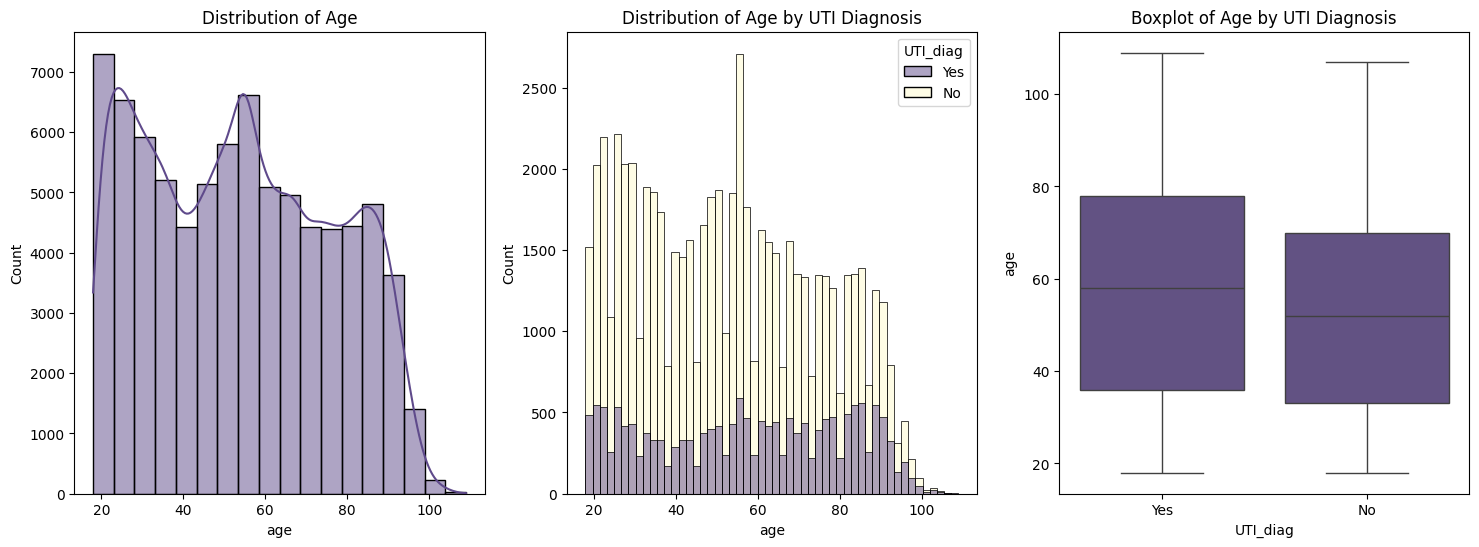

In [13]:
# plot the distribution of numerical features
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(data=df['age'], kde=True, ax=ax1, binwidth=5, color='#5f4a8b')
ax1.set_title('Distribution of Age')

sns.histplot(x='age', hue='UTI_diag', data=df, ax=ax2, palette=custom)
ax2.set_title('Distribution of Age by UTI Diagnosis')

sns.boxplot(x='UTI_diag', y='age', data=df, ax=ax3, palette=custom2)
ax3.set_title('Boxplot of Age by UTI Diagnosis')
plt.show()

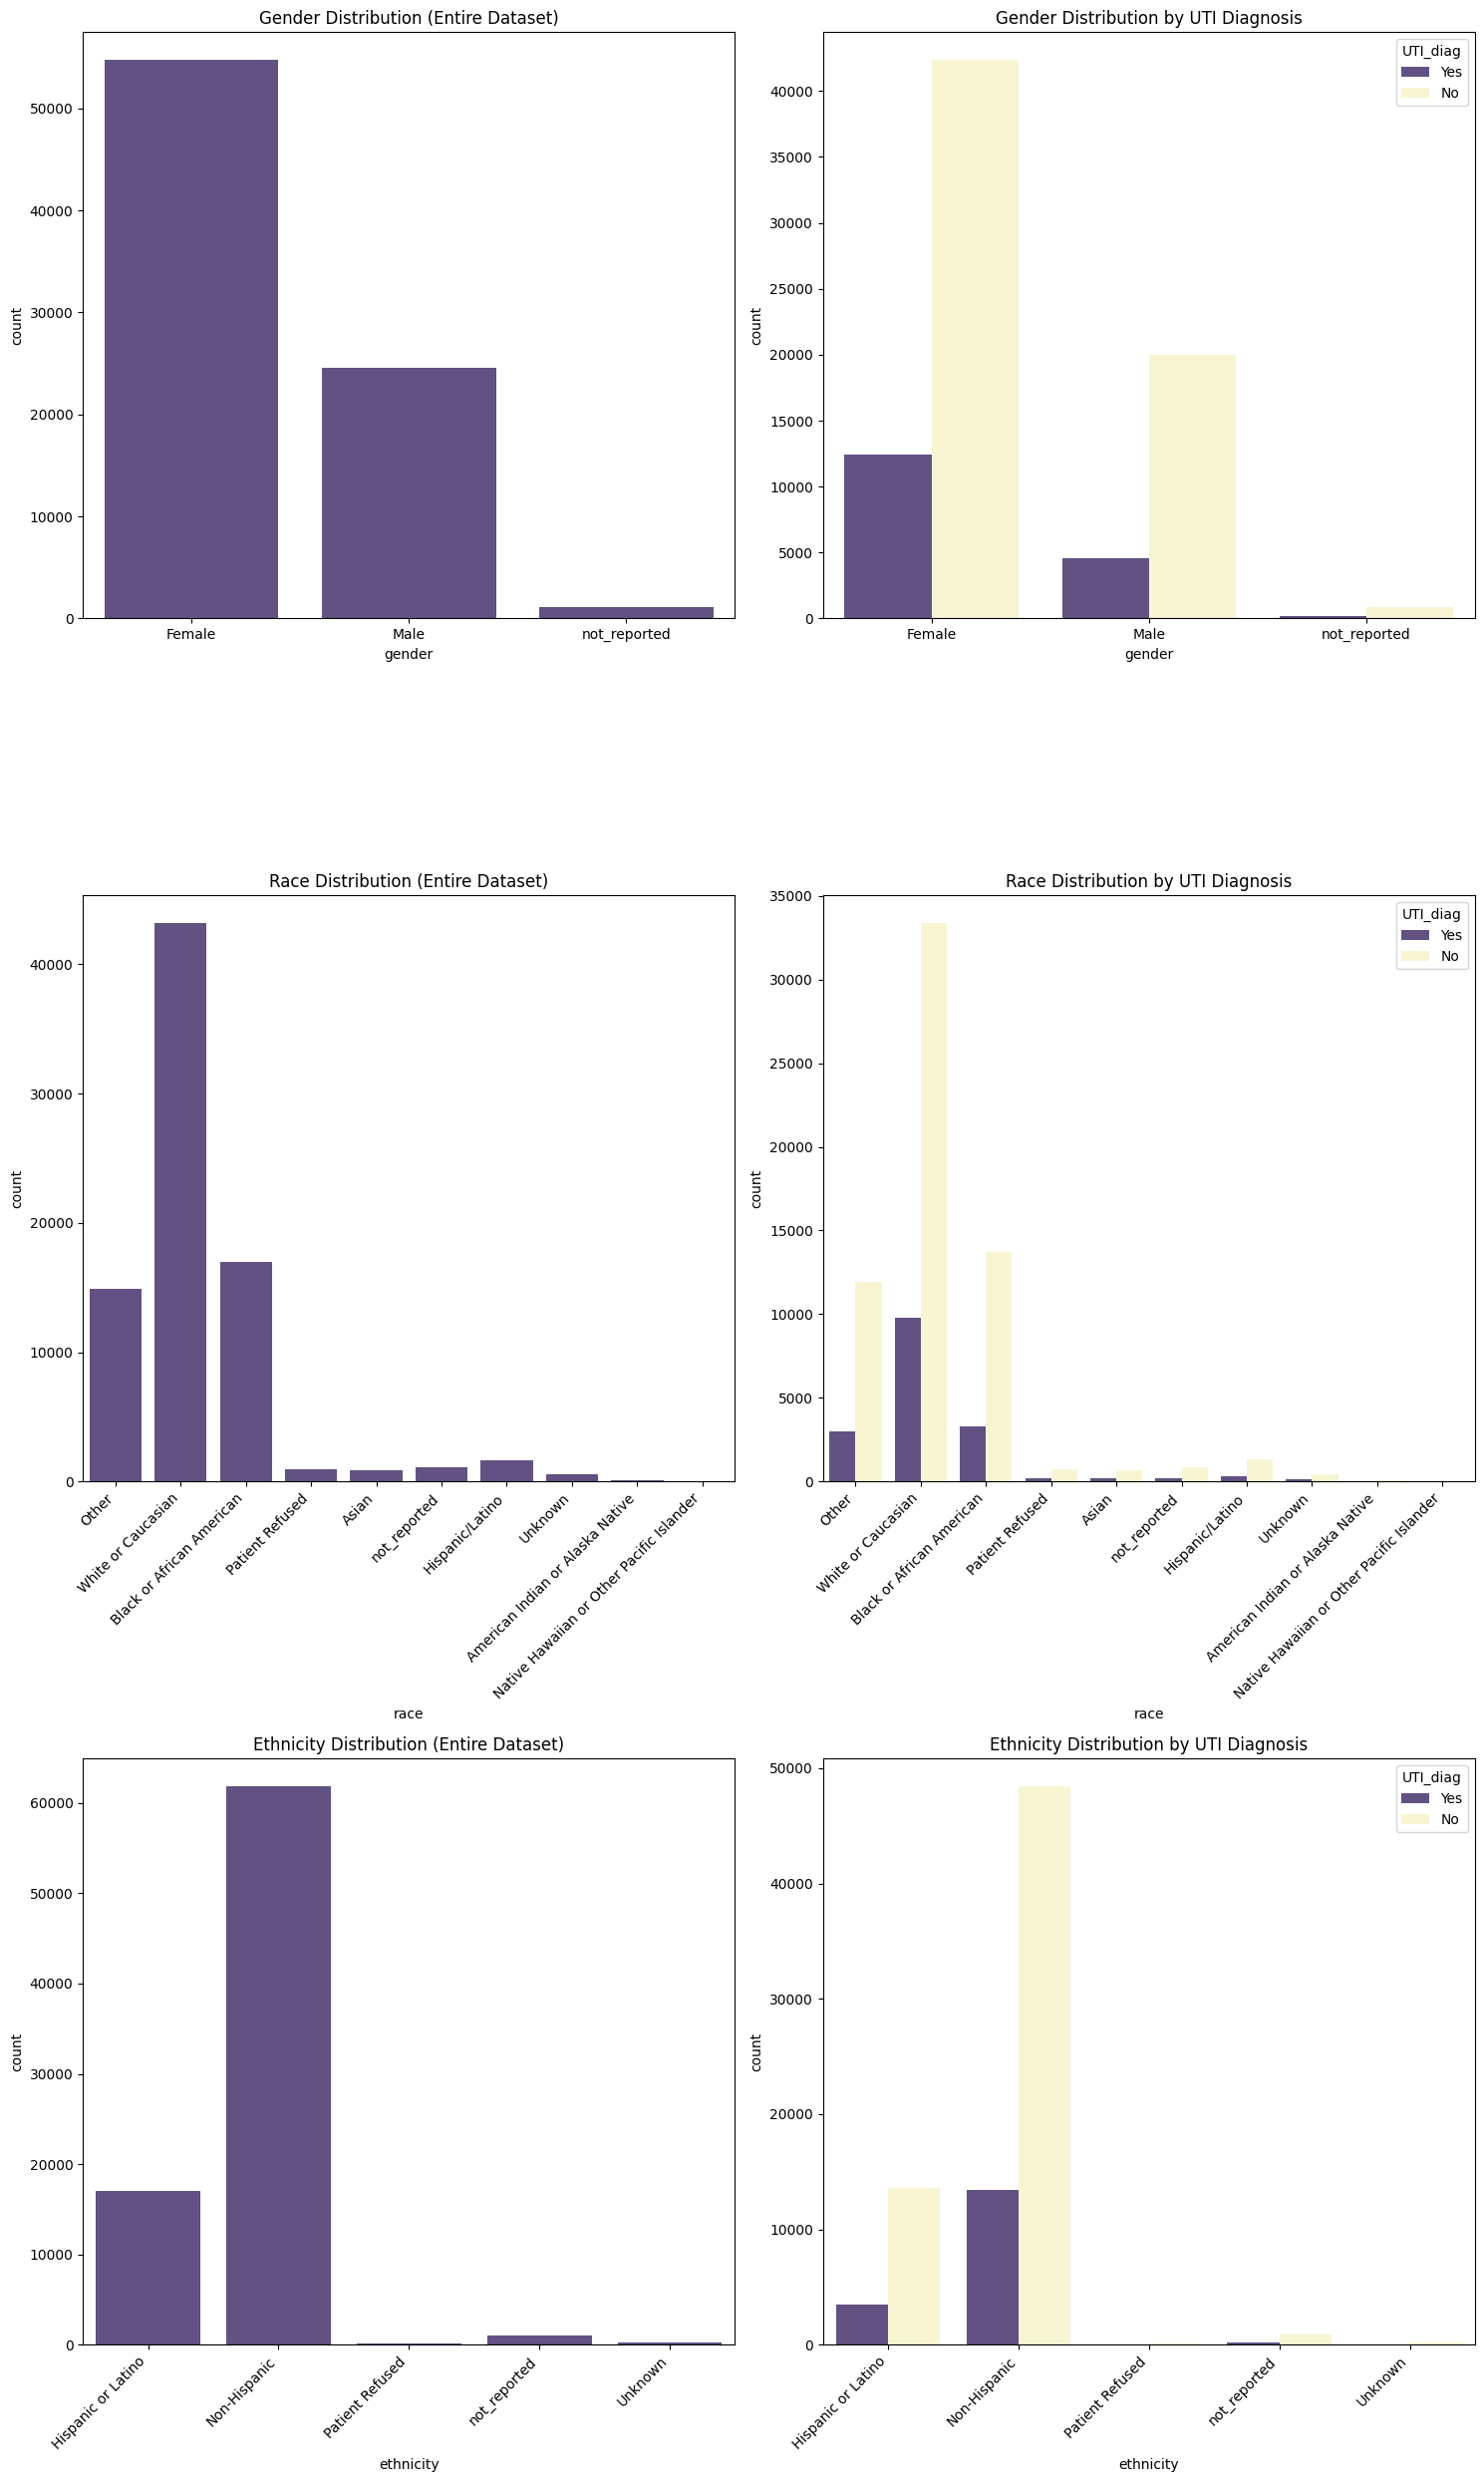

In [14]:
# distribution of gender for entire dataset
fig, axes = plt.subplots(3, 2, figsize=(15, 25))

sns.countplot(x='gender', data=df, ax=axes[0, 0], palette=custom)
axes[0, 0].set_title('Gender Distribution (Entire Dataset)')

# distribution of gender for UTI diagnosis
sns.countplot(x='gender', hue='UTI_diag', data=df, ax=axes[0, 1], palette=custom)
axes[0, 1].set_title('Gender Distribution by UTI Diagnosis')

# distribution of race for entire dataset
sns.countplot(x='race', data=df, ax=axes[1, 0], palette=custom2)
axes[1, 0].set_title('Race Distribution (Entire Dataset)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, horizontalalignment='right')

# distribution of race for UTI diagnosis
sns.countplot(x='race', hue='UTI_diag', data=df, ax=axes[1, 1], palette=custom2)
axes[1, 1].set_title('Race Distribution by UTI Diagnosis')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, horizontalalignment='right')

# distribution of ethinicity for entire dataset
sns.countplot(x='ethnicity', data=df, ax=axes[2, 0], palette=custom2)
axes[2, 0].set_title('Ethnicity Distribution (Entire Dataset)')
axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=45, horizontalalignment='right')

# distribution of ethinicity for UTI diagnosis
sns.countplot(x='ethnicity', hue='UTI_diag', data=df, ax=axes[2, 1], palette=custom2)
axes[2, 1].set_title('Ethnicity Distribution by UTI Diagnosis')
axes[2, 1].set_xticklabels(axes[2, 1].get_xticklabels(), rotation=45, horizontalalignment='right')

plt.tight_layout()
plt.show()

In [15]:
cat_cols.columns

Index(['UCX_abnormal', 'ua_bacteria', 'ua_bili', 'ua_blood', 'ua_clarity',
       'ua_color', 'ua_epi', 'ua_glucose', 'ua_ketones', 'ua_leuk',
       ...
       'PRE_NATAL_VITAMINS', 'PSYCHOTHERAPEUTIC_DRUGS', 'SEDATIVE_HYPNOTICS',
       'SKIN_PREPS', 'SMOKING_DETERRENTS', 'THYROID_PREPS',
       'UNCLASSIFIED_DRUG_PRODUCTS', 'VITAMINS', 'dispo', 'UTI_diag'],
      dtype='object', length=213)

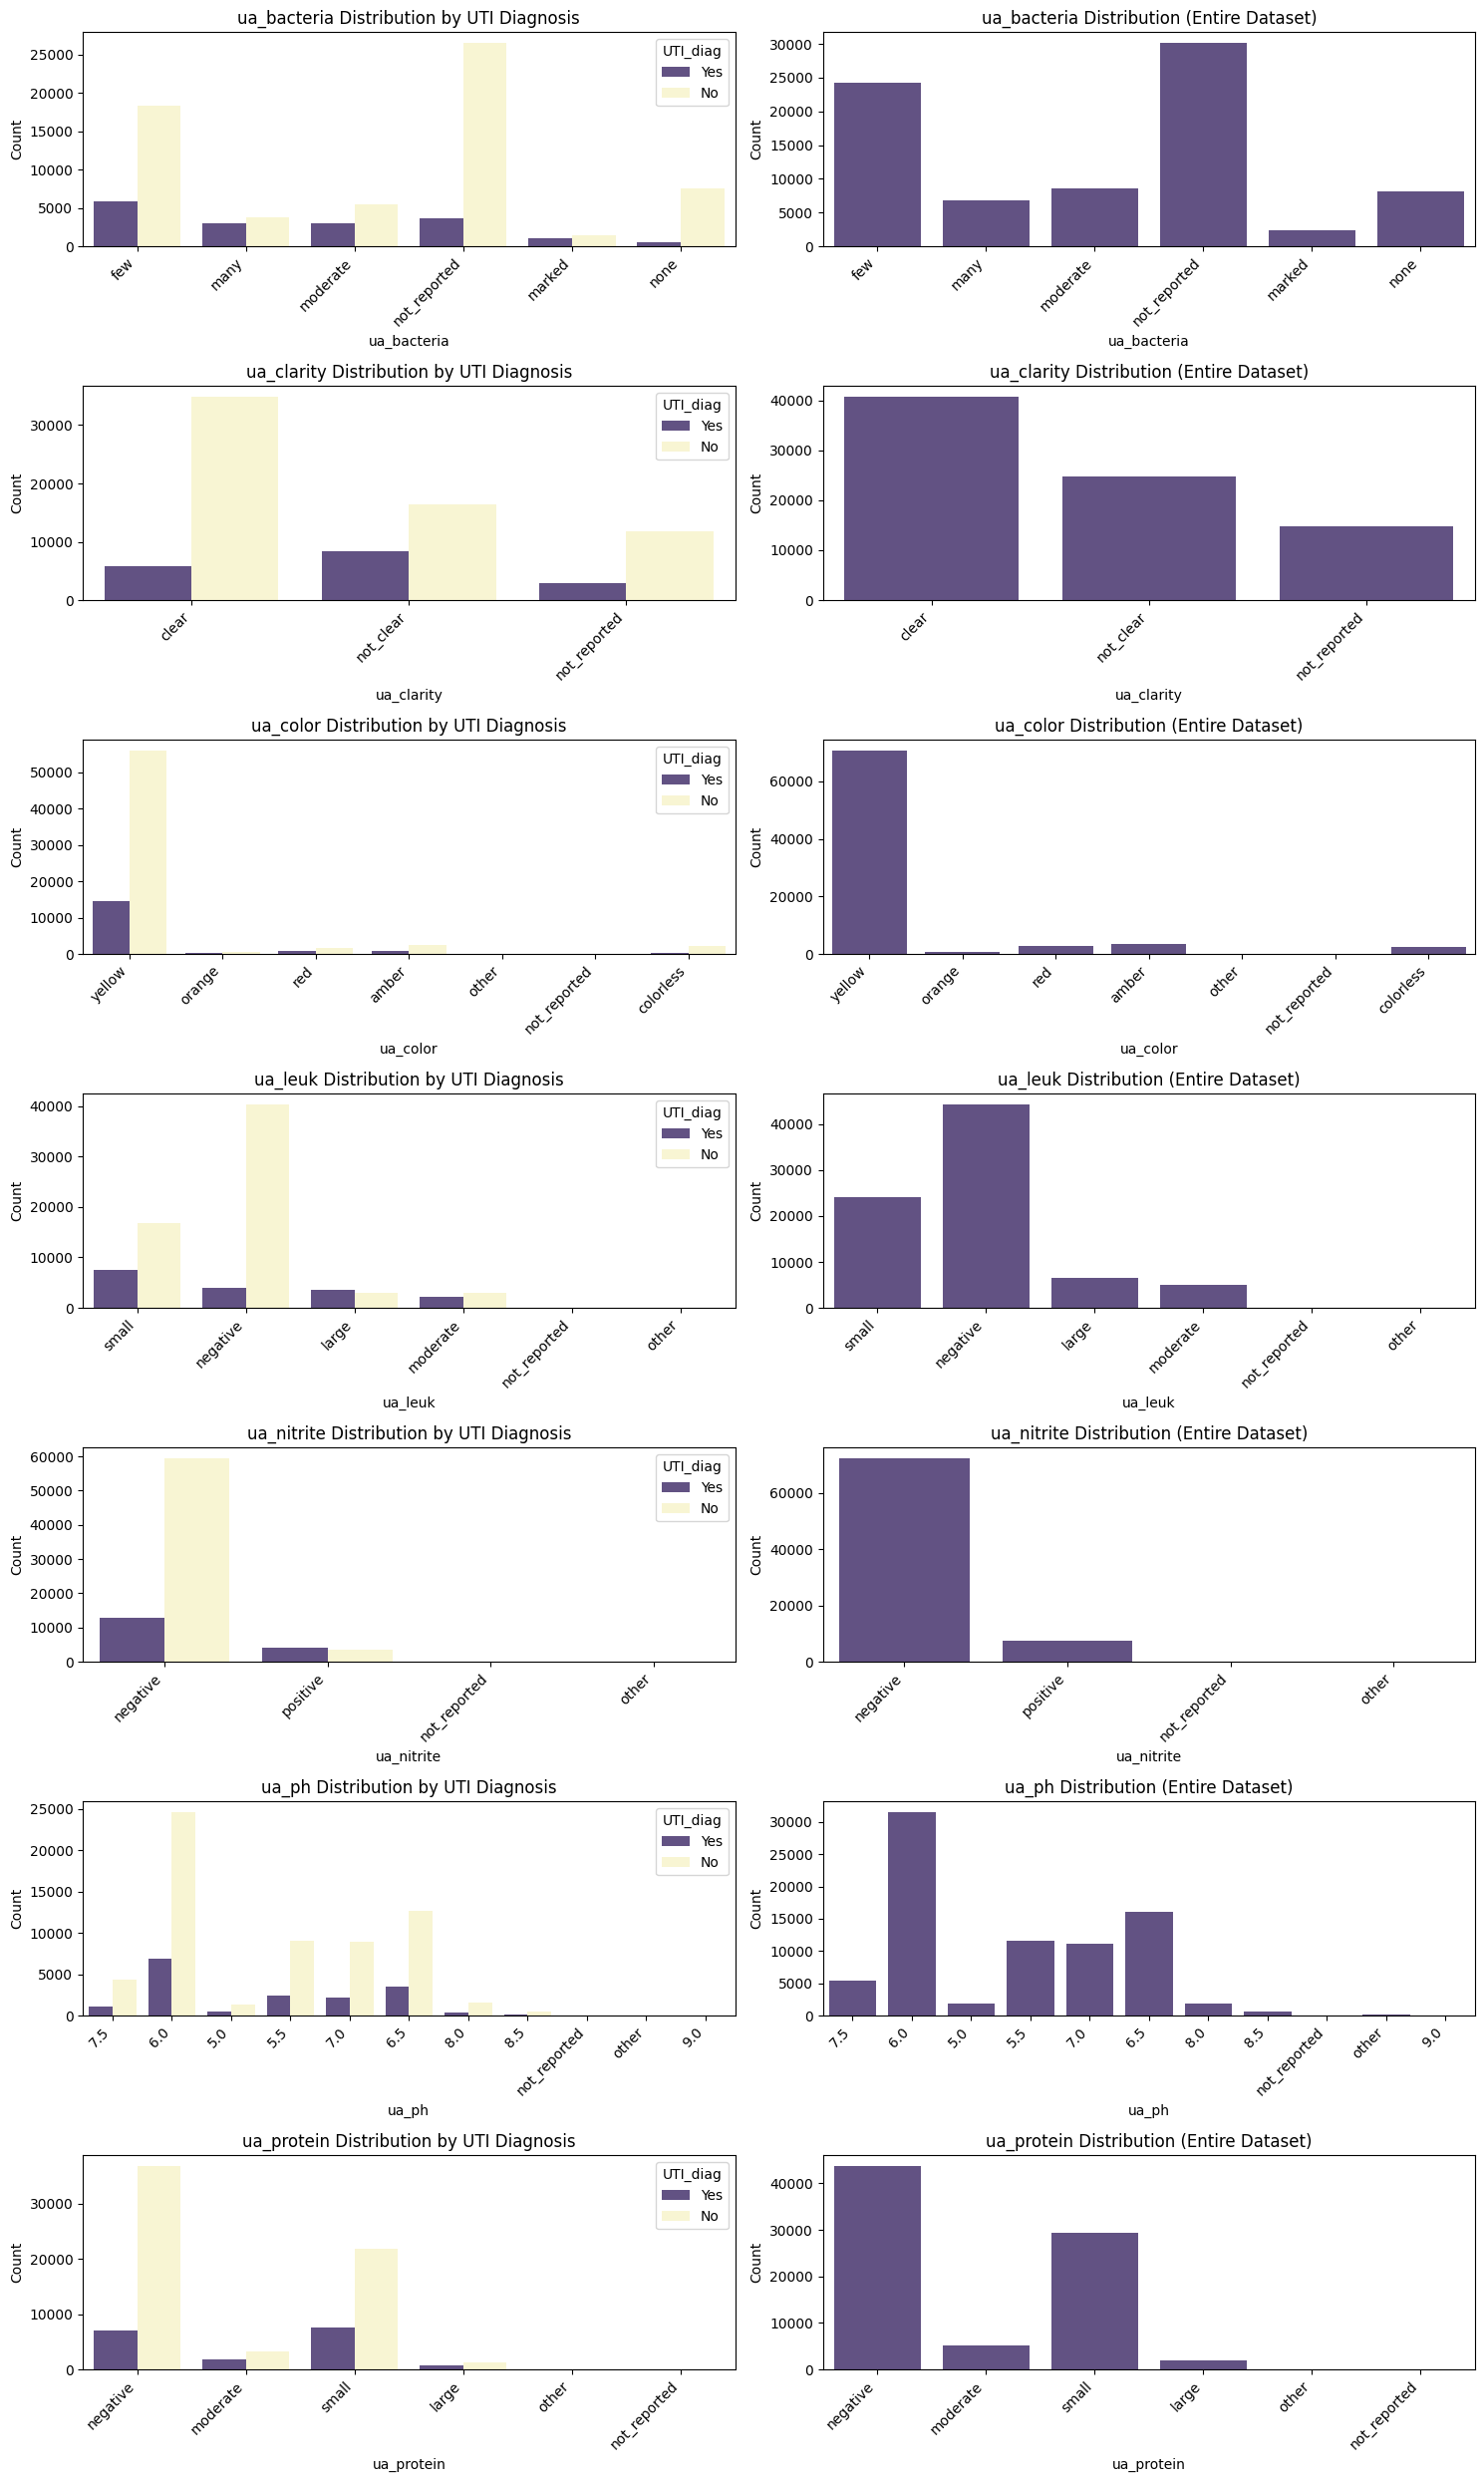

In [16]:
# Visualizing the distribution of urinalysis variables
ua_vars = ['ua_bacteria', 'ua_clarity', 'ua_color', 'ua_leuk', 'ua_nitrite', 'ua_ph', 'ua_protein']

# Plotting each variable threshold by UTI diagnosis
fig, axes = plt.subplots(nrows=len(ua_vars), ncols=2, figsize=(15, 25))
for i, var in enumerate(ua_vars):
    sns.countplot(x=var, hue='UTI_diag', data=df, ax=axes[i, 0], palette=custom)
    axes[i, 0].set_title(f'{var} Distribution by UTI Diagnosis')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].set_xticklabels(axes[i, 0].get_xticklabels(), rotation=45, horizontalalignment='right')

    # Plotting the distribution of the variable for the entire dataset
    sns.countplot(x=var, data=df, ax=axes[i, 1], palette=custom)
    axes[i, 1].set_title(f'{var} Distribution (Entire Dataset)')
    axes[i, 1].set_xlabel(var)
    axes[i, 1].set_ylabel('Count')
    axes[i, 1].set_xticklabels(axes[i, 1].get_xticklabels(), rotation=45, horizontalalignment='right')

plt.tight_layout()
plt.show()


In [17]:
df[cat_cols.columns].dtypes
df[cat_cols.columns] = df[cat_cols.columns].astype('str')
df[cat_cols.columns] = df[cat_cols.columns].apply(LabelEncoder().fit_transform)

In [18]:
# Chi-square test for each categorical variable
chi2_results = []

for col in df.columns:
    if col != 'UTI_diag':
        crosstab = pd.crosstab(df[col], df['UTI_diag'])
        chi2_stat, p_value,_, _ = stats.chi2_contingency(crosstab)
        chi2_results.append({'Variable': col, 'P_Value':p_value})

chi2_df = pd.DataFrame(chi2_results)

sig_vars = chi2_df[chi2_df['P_Value'] < 0.05]

print("Significant Variables based on Chi-Square Test:")
print(sig_vars)


Significant Variables based on Chi-Square Test:
                       Variable       P_Value
0                  UCX_abnormal  0.000000e+00
1                   ua_bacteria  0.000000e+00
2                       ua_bili  2.147676e-53
3                      ua_blood  0.000000e+00
4                    ua_clarity  0.000000e+00
..                          ...           ...
209          SMOKING_DETERRENTS  3.585234e-04
210               THYROID_PREPS  8.425235e-16
211  UNCLASSIFIED_DRUG_PRODUCTS  4.445210e-22
212                    VITAMINS  3.771085e-08
213                       dispo  3.426427e-14

[175 rows x 2 columns]


### Feature Selection

##### Using RandomForest and Chi_Square

In [19]:
# Seperating features and target variable
X = df.drop('UTI_diag', axis=1)
y = df['UTI_diag']

# Building a randomforest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = rf.feature_importances_

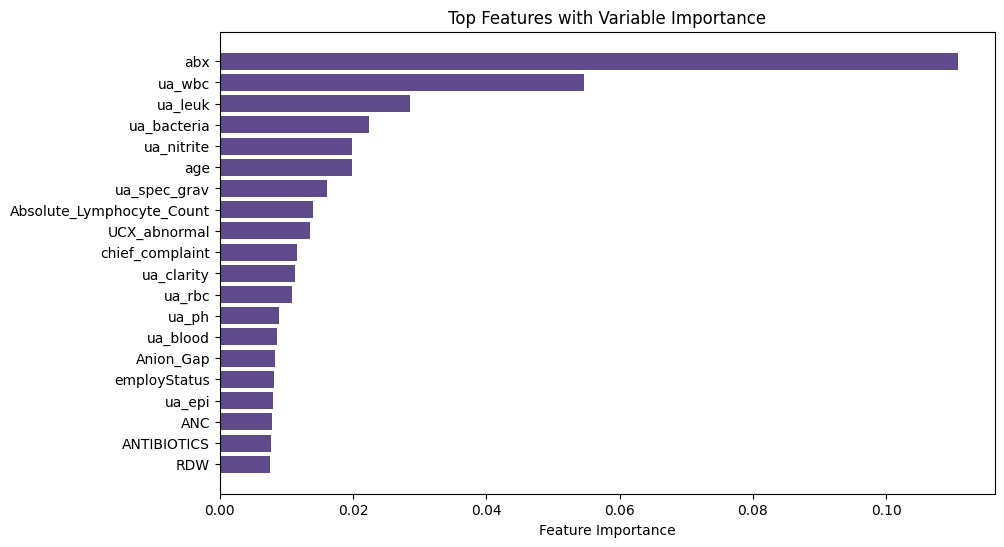

In [20]:
# sort feature importance in descending order
sorted_indices = np.argsort(feature_importance)[::-1]

top_n = 20
top_features = X.iloc[:, sorted_indices[:top_n]]

# select column names and the feature importance
top_features_names = X.columns[sorted_indices[:top_n]]
top_features_importances = feature_importance[sorted_indices[:top_n]]

# Bar plot for feature selection
plt.figure(figsize=(10, 6))
plt.barh(top_features_names, top_features_importances, color='#5f4a8b')
plt.xlabel('Feature Importance')
plt.title('Top Features with Variable Importance')
plt.gca().invert_yaxis()
plt.show()


In [21]:
# Selecting features using Chi-square 

X_new = df.drop(['UTI_diag'], axis=1)
y_new = df['UTI_diag']


# Chi-square as the score function create the feature_selection variable
feature_sel = SelectPercentile(score_func=chi2, percentile=20)
x = feature_sel.fit_transform(X_new, y_new)

fe = feature_sel.get_support()

selectedfeatures = []

for i in range(len(fe)):
    if fe[i]:
        selectedfeatures.append(X_new.columns[i])

if 'UTI_diag' in selectedfeatures:
    selectedfeatures.remove('UTI_diag')


print(selectedfeatures)

['UCX_abnormal', 'ua_bacteria', 'ua_clarity', 'ua_epi', 'ua_nitrite', 'ua_rbc', 'ua_wbc', 'abd_soft', 'back_pain', 'fever', 'alert', 'oriented', 'dysuria', 'chief_complaint', 'age', 'employStatus', 'arrival', 'Absolute_Lymphocyte_Count', 'Alanine_Aminotransferase', 'Alkaline_Phosphatase', 'Aspartate_Aminotransferase', 'Basophils', 'BUN', 'Calcium', 'CO2', 'Creatinine', 'Eosinophils', 'Glucose', 'Hematocrit', 'Hemoglobin', 'Lymphocytes', 'MCH', 'MCV', 'Monocytes', 'Neutrophils', 'Potassium', 'RBC', 'Sodium', 'WBC', 'abx', 'Delirium__dementia__and_amnestic_and_other_cognitive_disorders', 'Urinary_tract_infections', 'ANTIBIOTICS']


In [22]:
# Creating a new dataframe with the selected features
df_selected = df[top_features_names.tolist() + ['UTI_diag'] + ['gender']]
df_selected.head()


,abx,ua_wbc,ua_leuk,ua_bacteria,ua_nitrite,age,ua_spec_grav,Absolute_Lymphocyte_Count,UCX_abnormal,chief_complaint,...,ua_ph,ua_blood,Anion_Gap,employStatus,ua_epi,ANC,ANTIBIOTICS,RDW,UTI_diag,gender
0,1,1,5,0,0,83,1.020,5,1,0,...,5,2,0,2,5,0,0,0,1,0
1,1,5,2,1,0,81,1.017,5,0,21,...,2,5,2,5,3,2,0,1,1,0
2,0,5,5,0,0,78,1.016,5,1,1,...,0,2,1,5,5,0,0,3,0,0
3,1,1,0,1,0,84,1.016,5,1,10,...,1,2,2,5,3,3,0,1,1,0
4,0,5,5,3,3,55,1.030,5,0,0,...,2,2,1,1,3,3,0,1,0,1


#### Splitting data into training and testing sets


In [23]:
X = df_selected.drop('UTI_diag', axis=1)
y = df_selected['UTI_diag']

# Splitting the data into training, testing and validation sets
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [24]:
# Creating Evalution function to evaluate the model performance
def evaluate_model(model, X, y, label):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]  # Get probabilities for the positive class

    accuracy = accuracy_score(y, y_pred)
    class_report = classification_report(y, y_pred)

    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y, y_prob)
    pr_auc = auc(recall, precision)

    prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=10, strategy='uniform')

    print(f"{label} Evaluation:")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{class_report}")
    print(f"ROC AUC: {label}: {roc_auc:.2f}")
    print(f"PR AUC: {label}: {pr_auc:.2f}")

    # Plot ROC curve
    plt.figure(figsize=(15, 4))
    plt.subplot(2, 3, 1)
    plt.plot(fpr, tpr, color='#5f4a8b', label=f'ROC curve ({label}: AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2,linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({label})')
    plt.legend(loc="lower right")

    # Plot Precision-Recall curve
    plt.subplot(2, 3, 2)
    plt.plot(recall, precision, color='#5f4a8b', lw=2, label=f'PR curve ({label}: AUC = {pr_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve ({label})')
    plt.legend(loc="lower left")

    # Plot Calibration curve
    plt.subplot(2, 3, 3)
    plt.plot(prob_pred, prob_true, marker='o', lw=2, color='#5f4a8b', label=f'Calibration curve ({label})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Curve ({label})')
    plt.legend(loc="upper left")


### Building the Models

MODEL 1: Logistic Regression

(Validation Set) Evaluation:
Accuracy: 0.8198780942903346
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6365
           1       0.58      0.49      0.53      1674

    accuracy                           0.82      8039
   macro avg       0.73      0.70      0.71      8039
weighted avg       0.81      0.82      0.81      8039

ROC AUC: (Validation Set): 0.87
PR AUC: (Validation Set): 0.56
Logistic Regression (Test Set) Evaluation:
Accuracy: 0.8338101753949496
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      6413
           1       0.60      0.52      0.56      1626

    accuracy                           0.83      8039
   macro avg       0.74      0.72      0.73      8039
weighted avg       0.83      0.83      0.83      8039

ROC AUC: Logistic Regression (Test Set): 0.88
PR AUC: Logistic Regression (Test Set): 0.58


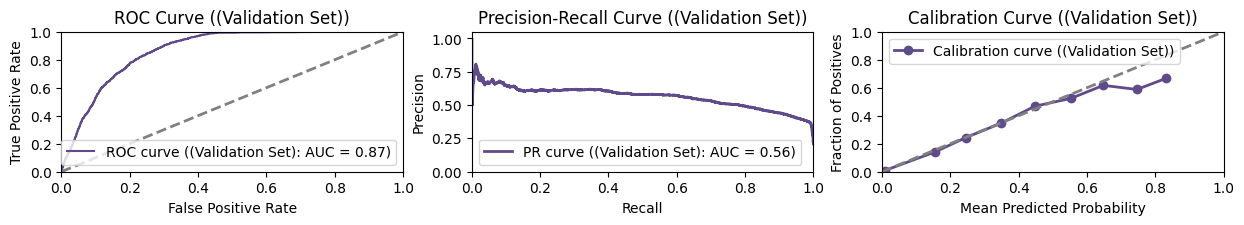

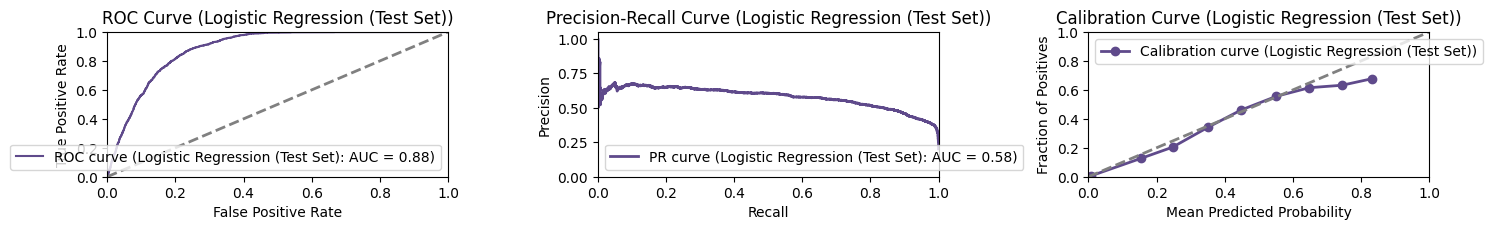

In [25]:
# Instantiating the models
log_reg = LogisticRegression()

log_reg.fit(x_train, y_train)

evaluate_model(log_reg, x_val, y_val, '(Validation Set)')

evaluate_model(log_reg, x_test, y_test, 'Logistic Regression (Test Set)')

plt.tight_layout()
plt.show()

MODEL 2: Random Forests

(Validation set) Evaluation:
Accuracy: 0.8527179997512129
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      6365
           1       0.66      0.60      0.63      1674

    accuracy                           0.85      8039
   macro avg       0.78      0.76      0.77      8039
weighted avg       0.85      0.85      0.85      8039

ROC AUC: (Validation set): 0.91
PR AUC: (Validation set): 0.69
Testing Evaluation:
Accuracy: 0.8584401044906083
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      6413
           1       0.66      0.62      0.64      1626

    accuracy                           0.86      8039
   macro avg       0.78      0.77      0.77      8039
weighted avg       0.86      0.86      0.86      8039

ROC AUC: Testing: 0.92
PR AUC: Testing: 0.71


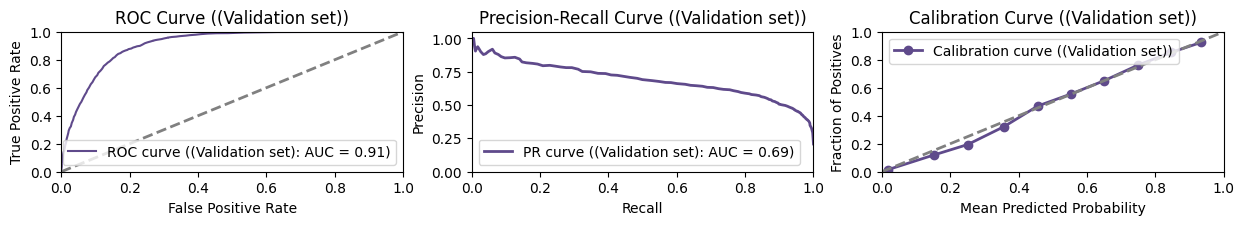

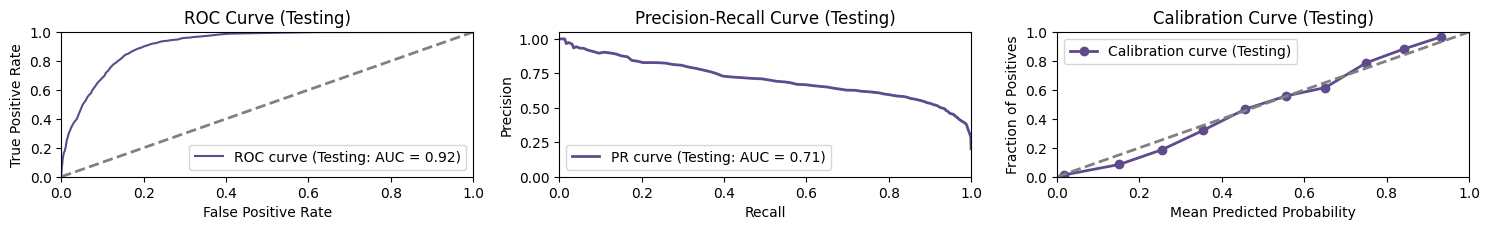

In [26]:
# Instantiate the model
rf = RandomForestClassifier()

rf.fit(x_train, y_train)


evaluate_model(rf, x_val, y_val, "(Validation set)")

evaluate_model(rf, x_test, y_test, "Testing")

plt.tight_layout()
plt.show()

MODEL 3: XgBoost

In [27]:
# Setup the Parameters for grid search
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 4, 5],
    'n_estimators': [100, 200, 300]
}

xgb = XGBClassifier()

grid_search = GridSearchCV(xgb, param_grid, scoring='accuracy', cv=5)
grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_

print(f"Best Parameters: {best_params}")



Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


Validation Set Evaluation:
Accuracy: 0.848613011568603
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      6365
           1       0.65      0.60      0.62      1674

    accuracy                           0.85      8039
   macro avg       0.77      0.76      0.76      8039
weighted avg       0.84      0.85      0.85      8039

ROC AUC: Validation Set: 0.91
PR AUC: Validation Set: 0.68
Testing Evaluation:
Accuracy: 0.8579425301654434
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      6413
           1       0.66      0.61      0.63      1626

    accuracy                           0.86      8039
   macro avg       0.78      0.77      0.77      8039
weighted avg       0.85      0.86      0.86      8039

ROC AUC: Testing: 0.91
PR AUC: Testing: 0.69


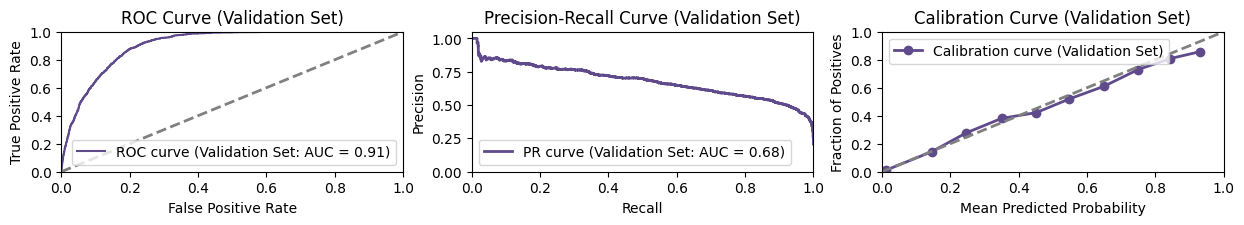

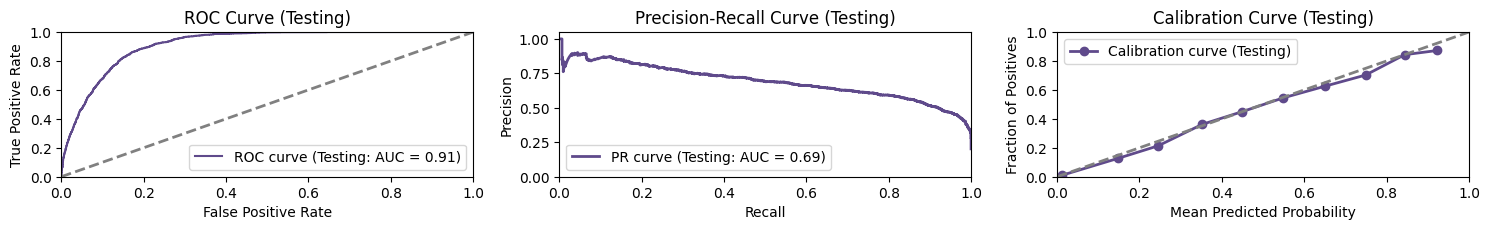

In [28]:
# Using the best parameters to instantiate the model
xgbc = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=300)

xgbc.fit(x_train, y_train)

evaluate_model(xgbc, x_val, y_val, "Validation Set")

evaluate_model(xgbc, x_test, y_test, "Testing")

plt.tight_layout()
plt.show()

In [29]:
# Create a function for the confusion matrix
def plot_confusion_matrix(y_true, y_pred, model):
    cnfm = confusion_matrix(y_true, y_pred)

    cmap = plt.get_cmap("PuBu")

    plt.imshow(cnfm, interpolation='nearest', cmap=cmap)
    plt.title(f'Confusion Matrix for {model}')
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ['Negative', 'Positive'])
    plt.yticks(tick_marks, ['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cnfm[i, j]), horizontalalignment='center', color='white' if cnfm[i, j] > cnfm.max() / 2 else 'black')

    plt.tight_layout()
    plt.show()


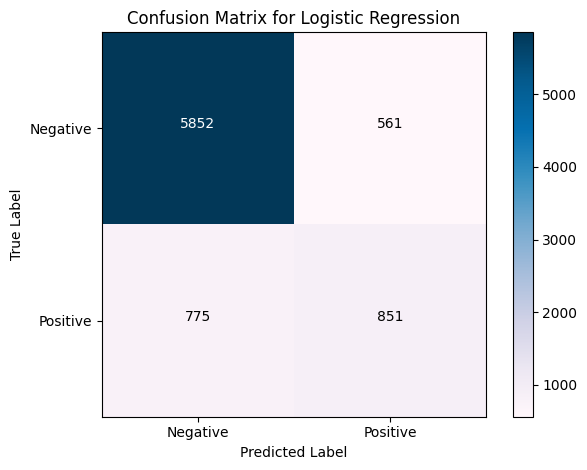

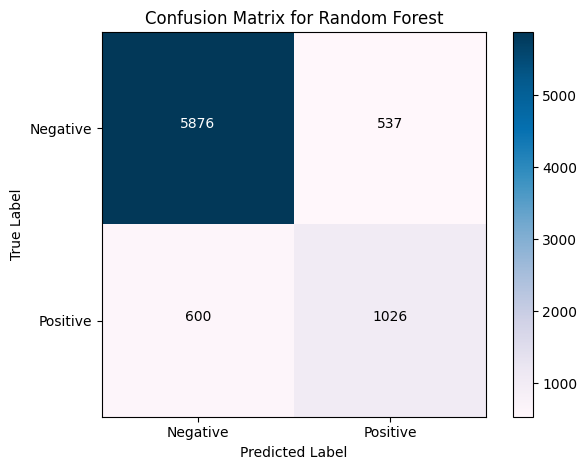

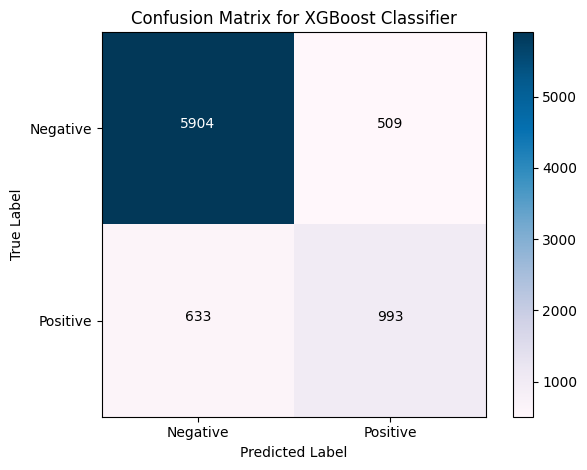

                 Model    TP    TN   FP   FN Sensitivity Specificity   AUC
0  Logistic Regression   851  5852  561  775        0.52        0.91  0.88
1        Random Forest  1026  5876  537  600        0.63        0.92  0.92
2   XGBoost Classifier   993  5904  509  633        0.61        0.92  0.91


In [30]:
# Creating the metrics list to evaluate the models
metrics = []

model_names = ["Logistic Regression", "Random Forest", "XGBoost Classifier"]

for model_name, model in zip(model_names, [log_reg, rf, xgbc]):
    y_test_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_test_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    auc_score = auc(fpr, tpr)

    metrics.append({
        'Model': model_name,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Sensitivity': f'{sensitivity:.2f}',
        'Specificity': f'{specificity:.2f}',
        'AUC': f'{auc_score:.2f}'
    })

    # Plot confusion matrix for each model
    plot_confusion_matrix(y_test, y_pred, model_name)

metrics_df = pd.DataFrame(metrics)

print(metrics_df)


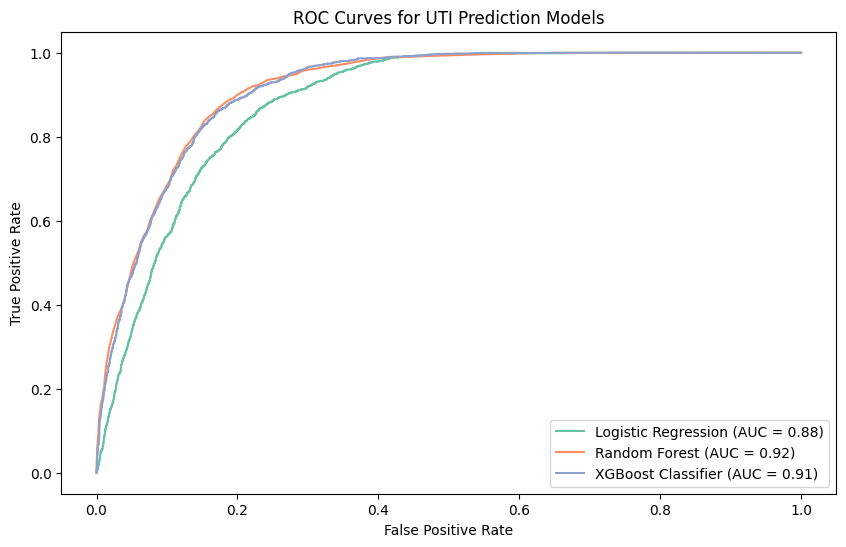

In [31]:
# Plotting ROC curves for all models
models = [log_reg, rf, xgbc]
plt.figure(figsize=(10, 6))

for model_name, model in zip(model_names, models):
    y_test_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    auc_score = roc_auc_score(y_test, y_test_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})', color=plt.get_cmap("Set2")(model_names.index(model_name)))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for UTI Prediction Models')
plt.legend(loc='lower right')
plt.show()

In [32]:
# Saving the models as pickle files
import pickle

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgbc, f)
    